# Phase 1 — The two scores (1a variance decomposition, 1b confound removal)

Input: OneK1K (Phase 0). Unit of analysis: **pseudobulk per donor × cell type** (summed raw UMIs, log2 CPM).
Every filtering step is logged with counts (`results/tables/onek1k_filter_log.csv`). Seed: `config.SEED`.

**Outcome of this run: STOP CONDITION 1b fired — see `FINDINGS.md`.** 1c/1d were therefore not run.

In [1]:
import os, sys, warnings
warnings.filterwarnings("ignore")
ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
os.chdir(ROOT); sys.path.insert(0, os.path.join(ROOT, "src"))
os.environ["PYTHONUTF8"] = "1"
from config import *
import subprocess
def sh(*args):
    """run a src/ script in a subprocess and embed its stdout in the notebook (child stdout bypasses the kernel otherwise)"""
    r = subprocess.run([sys.executable, *args], capture_output=True, text=True, encoding="utf-8", errors="replace")
    print(r.stdout)
    if r.returncode:
        print(r.stderr); raise RuntimeError(f"{args[0]} exited with {r.returncode}")
print("ROOT:", ROOT, "| SEED:", SEED)

ROOT: <repo> | SEED: 20260914


## 1.0 Pseudobulk construction
Cells → (donor, cell type) groups using the authors' Azimuth L2 labels (mapping in `src/run_pseudobulk_onek1k.py`).
Groups with <20 cells and cell types present in <100 donors are dropped (logged). Per-pseudobulk covariates recorded:
n_cells, mean UMI/cell, mean genes/cell, cell-cycle UMI fraction, fraction of cells expressing proliferation markers, pool, sex.

In [2]:
sh("src/run_pseudobulk_onek1k.py")
import pandas as pd
pd.read_csv(TAB / "onek1k_filter_log.csv")

[cached] <repo>\data\processed\onek1k_pseudobulk.h5ad exists; skipping build



,step,unit,before,after,removed,note
0,cells with numeric donor age,cells,1248980,1248980,0,non-numeric development_stage dropped
1,cells whose cell type is in the analysis map,cells,1248980,1243859,5121,"dropped raw labels: ['CD4 Proliferating', 'CD8..."
2,pseudobulk groups with >= 20 cells,groups,19754,9681,10073,NaN
3,cells in retained pseudobulk groups,cells,1243859,1170622,73237,NaN
4,cell types present in >= 100 donors,cell types,21,16,5,"dropped: {'NK_CD56bright': np.int64(33), 'Plas..."
5,cells in retained cell types,cells,1170622,1168986,1636,NaN


## 1a. Variance decomposition
Model (as specified): `expression ~ C(cell_type) + age`, OLS per gene on log2-CPM pseudobulks. Commonality partition:
`unique_ct = R²(full) − R²(age)`, `unique_age = R²(full) − R²(ct)`, `shared = R²(ct)+R²(age)−R²(full)`, `resid = 1 − R²(full)`.
Extras: interaction (`C(cell_type)*age`) and `partial_age` (fraction of within-cell-type variance explained by age).

**Why this model** (see FINDINGS.md §1a): pseudobulking removes cell-level Poisson noise and cell-level confounders, makes the
design almost balanced (every donor contributes most cell types, so `shared ≈ 0` and the partition is unambiguous), and puts
age and cell type on the same footing as *donor-level* vs *type-level* sources of variance. A per-cell model would let cell-type
composition and cell-level depth dominate the age term.

Threshold sweep: the grid was recalibrated after the first look at the distribution (initial a-priori grid gave empty A sets);
this happened before any downstream model existed and is recorded in `src/decomp.py` and `results/phase1a_decomp_initial.txt`.

In [3]:
from run_1a_decomp import main as run_1a
df = run_1a()

pseudobulk: 9,623 samples x 35,528 genes; donors=981; cell types=16
                n_pseudobulks  n_donors  median_cells
celltype                                             
B_intermediate            493       493          32.0
B_memory                  614       614          35.0
B_naive                   844       844          62.0
CD4_CTL                   280       280          36.0
CD4_Naive                 974       974         246.0
CD4_TCM                   980       980         276.5
CD4_TEM                   698       698          34.0
CD8_Naive                 671       671          54.0
CD8_TCM                   293       293          26.0
CD8_TEM                   966       966         136.0
CD14_Mono                 493       493          49.0
CD16_Mono                 293       293          31.0
MAIT                      112       112          27.0
NK                        977       977         147.0
Treg                      606       606          31.0
gdT           

[filter] genes with CPM>1 in >= 10% of pseudobulks   genes  35,528 -> 13,904  (removed 21,624)
[filter] drop CELLxGENE feature_is_filtered genes                genes  13,904 -> 13,904  (removed 0)



=== variance component distribution over genes (fraction of total variance) ===
             0.500  0.900  0.950  0.990  0.999  1.000
unique_ct   0.1260 0.5163 0.6731 0.8538 0.9212 0.9687
unique_age  0.0002 0.0018 0.0029 0.0074 0.0215 0.0350
shared      0.0001 0.0016 0.0025 0.0048 0.0085 0.0150
resid       0.8730 0.9481 0.9622 0.9776 0.9851 0.9908
interaction 0.0025 0.0041 0.0046 0.0060 0.0100 0.0151
partial_age 0.0003 0.0026 0.0044 0.0124 0.0352 0.0588

shared component: min=-0.0110 max=0.0150 (near 0 => age and cell type ~orthogonal in design)

Top 25 genes by unique age variance:
                          symbol  unique_age  unique_ct  interaction  age_slope_per_year  mean_logcpm
ENSG00000101745          ANKRD12      0.0350     0.4078       0.0027              0.0067       7.2750
ENSG00000157514          TSC22D3      0.0350     0.2514       0.0019              0.0072       9.0306
ENSG00000173812             EIF1      0.0294     0.3381       0.0014              0.0035      10.9802
E


=== set sizes: A-genes by (t_age, k_ct) [I thresholds fixed t_ct=0.5,k_age=0.001] ===
k_ct   0.1  0.2  0.3   0.5
t_age                     
0.002  328  700  872  1096
0.005   65  140  170   242
0.010   13   30   39    64
0.020    6   10   11    19

=== set sizes: MIXED by (t_age, t_ct) [k_ct=0.2,k_age=0.001] ===
t_ct   0.3  0.5  0.7
t_age               
0.002  384  160   45
0.005  113   41   10
0.010   37   12    1
0.020    8    0    0

=== set sizes: I-genes by (t_ct, k_age) [t_age=0.005,k_ct=0.2] ===
k_age  0.0005  0.0010  0.0020  0.0050
t_ct                                 
0.3      1892    2294    2650    2921
0.5       978    1164    1317    1436
0.7       448     511     558     593

=== PRIMARY thresholds {'t_age': 0.005, 'k_ct': 0.2, 't_ct': 0.5, 'k_age': 0.001} ===
gene_class
OTHER    12559
I         1164
A          140
MIXED       41
A-genes (primary): SET, RIPOR2, DCK, HNRNPH1, ENSG00000260613, C6orf62, C1orf56, SRSF6, DONSON, RBIS, GABRE, EIF3F, PPP1CB, RSL24D1, ARRDC3, LS


=== sensitivity: pseudobulks with >=100 cells only (n=3,486; cell types=['CD4_TCM', 'CD4_Naive', 'NK', 'CD8_TEM', 'B_naive', 'CD8_Naive']) ===
             0.500  0.900  0.950  0.990  0.999  1.000
unique_ct   0.1759 0.6650 0.7764 0.9004 0.9463 0.9738
unique_age  0.0006 0.0056 0.0093 0.0192 0.0347 0.0756
resid       0.8208 0.9798 0.9888 0.9959 0.9988 0.9996
partial_age 0.0009 0.0091 0.0153 0.0330 0.0547 0.0999


Spearman(unique_age all vs >=100-cell): 0.640



Batch check: age ~ C(pool) across 981 donors, 75 pools: R2=0.234, adj R2=0.172, F p=3.81e-21



Mean partition over genes: {'unique_ct': 0.2071, 'unique_age': 0.0007, 'shared': 0.0005, 'interaction': 0.0026, 'resid': 0.7892}


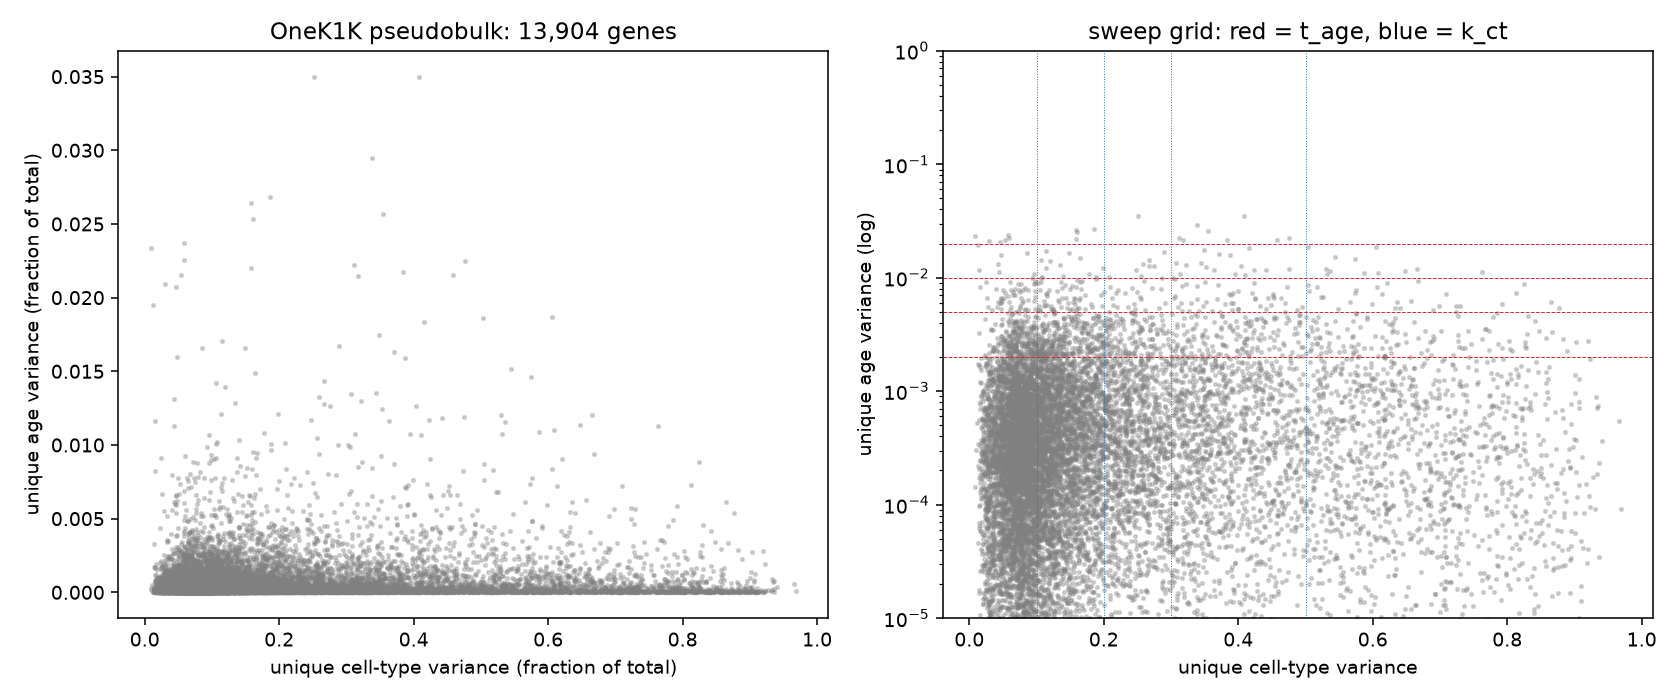

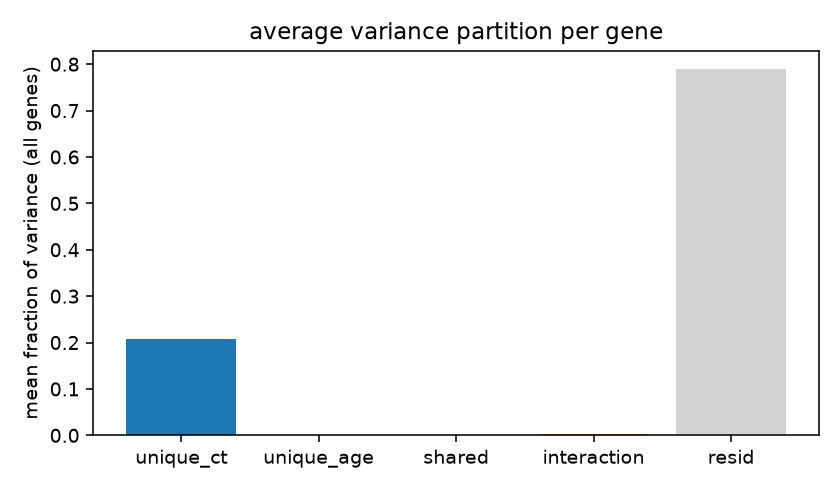

In [4]:
from IPython.display import Image, display
display(Image(str(FIG / "phase1a_joint_variance_distribution.png")))
display(Image(str(FIG / "phase1a_mean_variance_partition.png")))

## 1b. Confound removal
Flags: Tirosh S/G2M + proliferation list; data-driven cycling (|r| ≥ 0.3 with cell-cycle UMI fraction / proliferating-cell
fraction, within cell type); ribosomal; mitochondrial; chrX/chrY (Ensembl) + within-type sex DE; depth (|r| ≥ 0.3 with mean
UMI/cell or genes/cell, within cell type). Plus a **batch check**: age variance retained after adding the 10x `pool` to the model.

In [5]:
from run_1b_confounds import main as run_1b
F = run_1b()

=== covariates vs age (is proliferation / depth itself age-associated?) ===
Spearman(age, covariate) within cell type:
covariate       cc_umi_frac  mean_counts_per_cell  mean_genes_per_cell  n_cells  prolif_marker_cell_frac
celltype                                                                                                
B_intermediate       +0.125                +0.136               +0.117   -0.013                   -0.003
B_memory             +0.061                +0.174               +0.151   -0.164                   +0.072
B_naive              +0.007                +0.177               +0.139   +0.003                   +0.050
CD14_Mono            -0.122                +0.156               +0.099   +0.062                   -0.034
CD16_Mono            +0.094                +0.111               +0.079   +0.059                   +0.031
CD4_CTL              +0.117                +0.068               +0.056   +0.030                   +0.079
CD4_Naive            -0.089              


=== genome-wide flag counts (all 13,904 expressed genes) ===
  flag_cc_list          144
  flag_cc_data           69
  flag_cell_cycle       195
  flag_ribo             157
  flag_mito              13
  flag_sex_chrom        462
  flag_sex_data          25
  flag_sex              463
  flag_depth            236
  flag_technical        355

=== PRIMARY A-genes: n=140 (thresholds {'t_age': 0.005, 'k_ct': 0.2, 't_ct': 0.5, 'k_age': 0.001}) ===
                                                     filter  flagged_marginal  removed_incremental  surviving
             cell-cycle (Tirosh S/G2M + proliferation list)                 1                    1        139
        cell-cycle (data: |r|>=0.3 with cycling covariates)                 2                    2        137
                                    ribosomal (RPL/RPS/MRP)                 0                    0        137
                                        mitochondrial (MT-)                 2                    2        135
    

In [6]:
from run_1b_batch_verify import main as verify
verify()

=== (a) simulation: expected within-pool retention for a REAL age effect ===


       unique_age  within_pool  retained_mean  retained_min
beta                                                       
0.005      0.0051       0.0066         1.2962        1.1311
0.010      0.0259       0.0250         0.9647        0.8694
0.020      0.1066       0.0914         0.8573        0.8149
expected retention ~ 1 - R2(age~pool) = 0.766   (observed median for primary A-genes: 0.034)

=== (b) is per-cell depth a pool-level (batch) property? ===
   R2( log mean_counts_per_cell [cell-type-residualized] ~ C(pool) ) = 0.855
   R2( log mean_genes_per_cell [cell-type-residualized] ~ C(pool) ) = 0.812
   donor-level corr(age, depth): between-pool means r=+0.432 (n=75 pools); within-pool r=-0.034

=== (c) genome-wide: within-pool unique age variance ===


                         0.500   0.900   0.950   0.990   0.999   1.000
pooled unique_age      0.00024 0.00183 0.00291 0.00736 0.02154 0.03500
within-pool unique_age 0.00010 0.00062 0.00092 0.00184 0.00454 0.01262
   genes with unique_age >= 0.002: pooled=1256, within-pool=116, both=85
   genes with unique_age >= 0.005: pooled=283, within-pool=10, both=9
   genes with unique_age >= 0.01: pooled=76, within-pool=2, both=1
Spearman(pooled unique_age, within-pool unique_age) over all genes: 0.337

Top 25 genes by WITHIN-POOL unique age variance:
                   symbol  unique_age_within_pool  unique_age  unique_ct  r_mean_counts  flag_cell_cycle  flag_technical  flag_sex
ENSG00000138326     RPS24                  0.0126      0.0006     0.4102         0.4639            False            True     False
ENSG00000124766      SOX4                  0.0123      0.0215     0.4578        -0.0880            False           False     False
ENSG00000157514   TSC22D3                  0.0098      0.035

                          symbol  r_age_pooled  r_age_within_pool  r_mean_counts
ENSG00000119335              SET        -0.181             -0.048         -0.578
ENSG00000111913           RIPOR2        -0.177             -0.041         -0.349
ENSG00000156136              DCK        -0.174             -0.048         -0.363
ENSG00000169045          HNRNPH1        -0.158             -0.008         -0.709
ENSG00000260613  ENSG00000260613        +0.154             +0.008         +0.398
ENSG00000112308          C6orf62        -0.154             -0.007         -0.511
ENSG00000143443          C1orf56        -0.161             -0.013         -0.676
ENSG00000124193            SRSF6        -0.151             -0.010         -0.476
ENSG00000159147           DONSON        +0.147             -0.001         +0.325
ENSG00000176731             RBIS        +0.148             -0.022         +0.508
ENSG00000102287            GABRE        +0.141             -0.010         +0.358
ENSG00000175390            E

   null (age permuted within pool at donor level): 99th pct |r| = 0.031, max=0.080


In [7]:
from run_1b_depth_mediator import main as mediator
mediator()

Primary A-genes (n=140): fraction of pooled age variance retained after adjusting for...
   depth covariates only (2 df)     median=0.228  mean=0.285  n(<0.25)=74  n(<0.5)=118
   pool only (74 df)                median=0.034  mean=0.073  n(<0.25)=131  n(<0.5)=136
   pool + depth                     median=0.039  mean=0.078  n(<0.25)=131  n(<0.5)=136

All genes with pooled unique_age >= 0.002 (n=1256):
   depth only     median retention=0.336; genes still >=0.002: 327
   pool only      median retention=0.087; genes still >=0.002: 85
   pool + depth   median retention=0.094; genes still >=0.002: 87


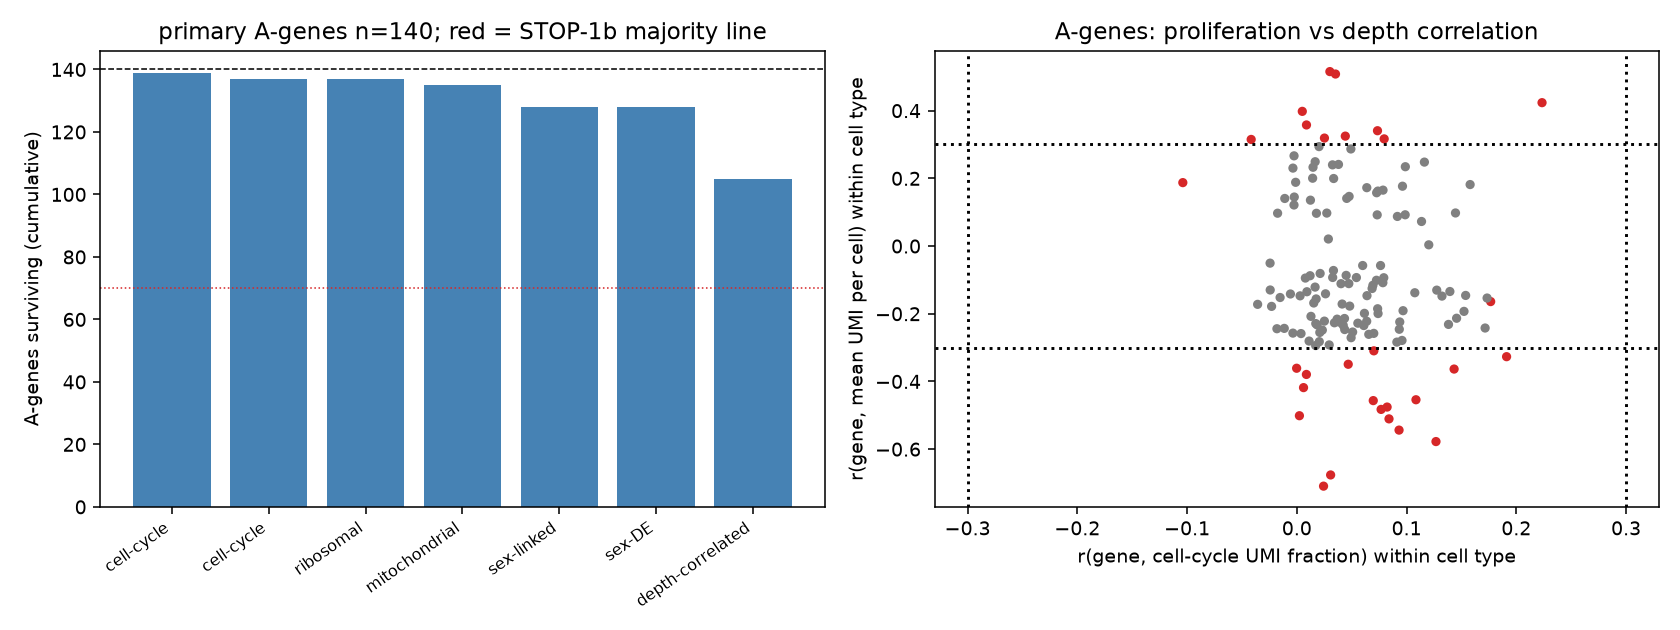

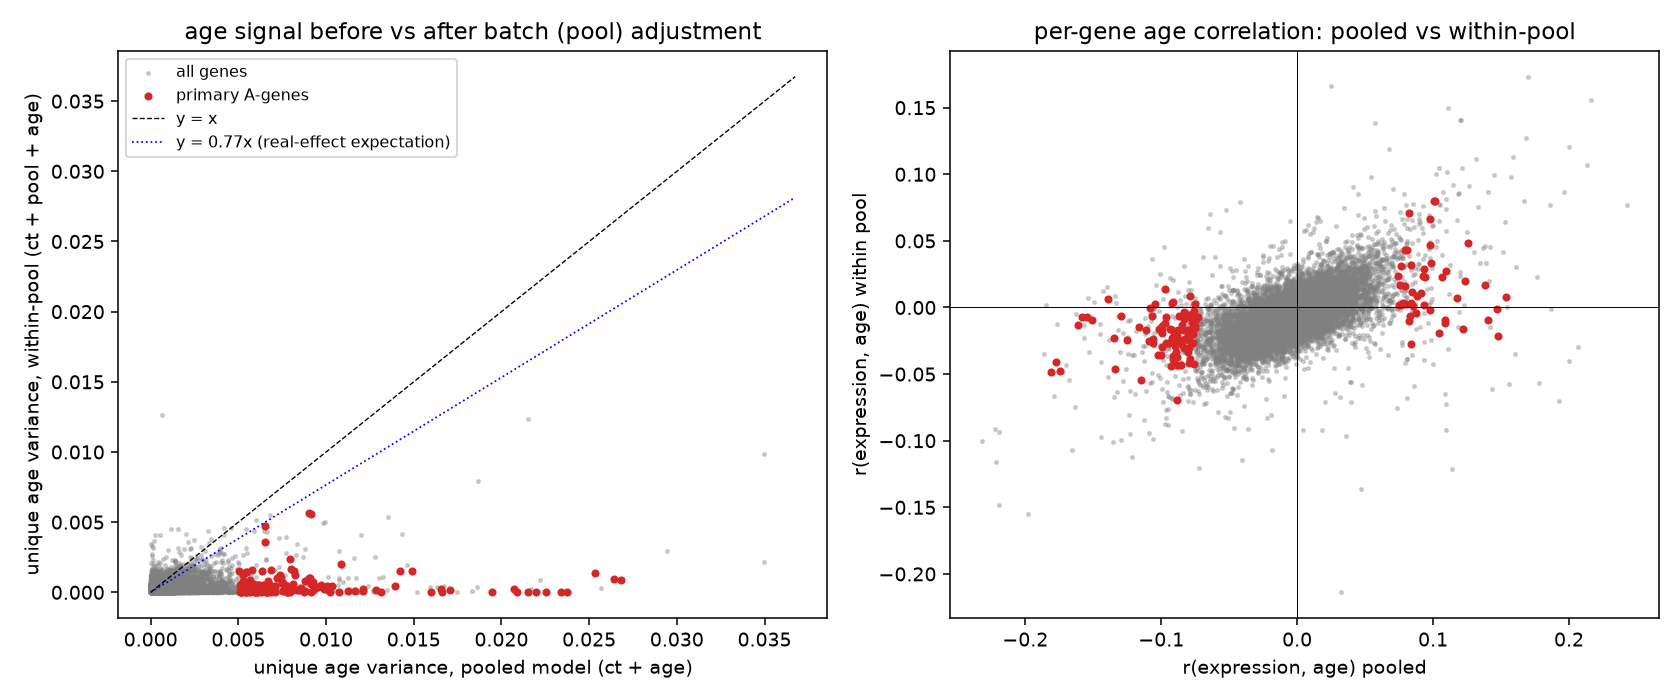

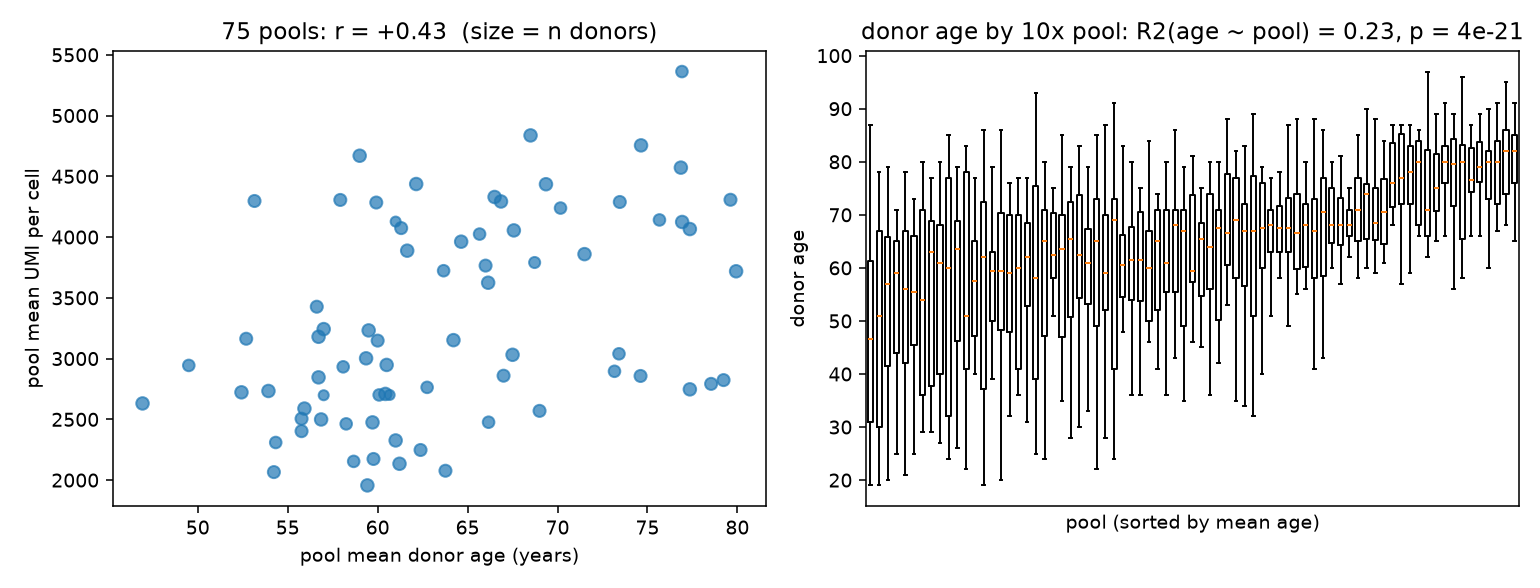

In [8]:
display(Image(str(FIG / "phase1b_Agene_confound_filters.png")))
display(Image(str(FIG / "phase1b_batch_adjustment_age_signal.png")))
display(Image(str(FIG / "phase1b_pool_age_depth_confound.png")))

## STOP CONDITION 1b — verdict
By the literal pre-specified flags 29/140 (20.7%) of primary A-genes are cell-cycle or technical. But the batch analysis shows the
A-gene set is dominated by a **technical artifact**: 136/140 (97%) retain <50% of their age variance after adjusting for 10x pool
(a real effect retains ≥ ~77%, confirmed by simulation), depth covariates alone do the same for 118/140 (84%), and within-pool the
A-genes' age correlation is below the permutation null. Mechanism: donors were not age-randomized across pools; per-cell UMI depth is a
pool property (R² = 0.86); depth correlates with age between pools (r = +0.43) and not within (r = −0.03).

Per the operating mode, Phase 1 halts here. 1c (score models) and 1d (negative controls) were **not run**. See `FINDINGS.md`.

In [9]:
from run_1b_verdict import main as verdict
fired = verdict()
assert fired, "verdict changed — FINDINGS.md must be revisited"
print("\nPhase 1 halted at 1b. 1c/1d not executed.")

STOP CONDITION 1b — VERDICT (primary A-genes, thresholds {'t_age': 0.005, 'k_ct': 0.2, 't_ct': 0.5, 'k_age': 0.001})
A-genes: 140
(i)  literal flags — cell-cycle: 3; cell-cycle OR technical (ribo/mito/depth|r|>=0.3): 29/140 = 20.7%
(ii) mechanism — age variance retained after adjusting for 10x pool: median 0.034 (expected >= ~0.77 for a real effect); genes retaining < 50%: 136/140 = 97.1%
     mechanism — age variance retained after adjusting for depth covariates only (2 df): median 0.228; genes retaining < 50%: 118/140 = 84.3%
     union (cell-cycle OR literal technical OR batch/depth-mediated): 136/140 = 97.1%
     of which cell-cycle: 3 (2.1%) — proliferation is NOT the dominant confound

VERDICT: STOP CONDITION 1b FIRED.
  The majority of A-genes are technical artifacts: their donor-age association is mediated by 10x-pool batch and the
  pool-level sequencing depth (UMI per cell), which is confounded with donor age (R2(age~pool)=0.23; between-pool r(age,depth)=+0.43;
  within-pool 